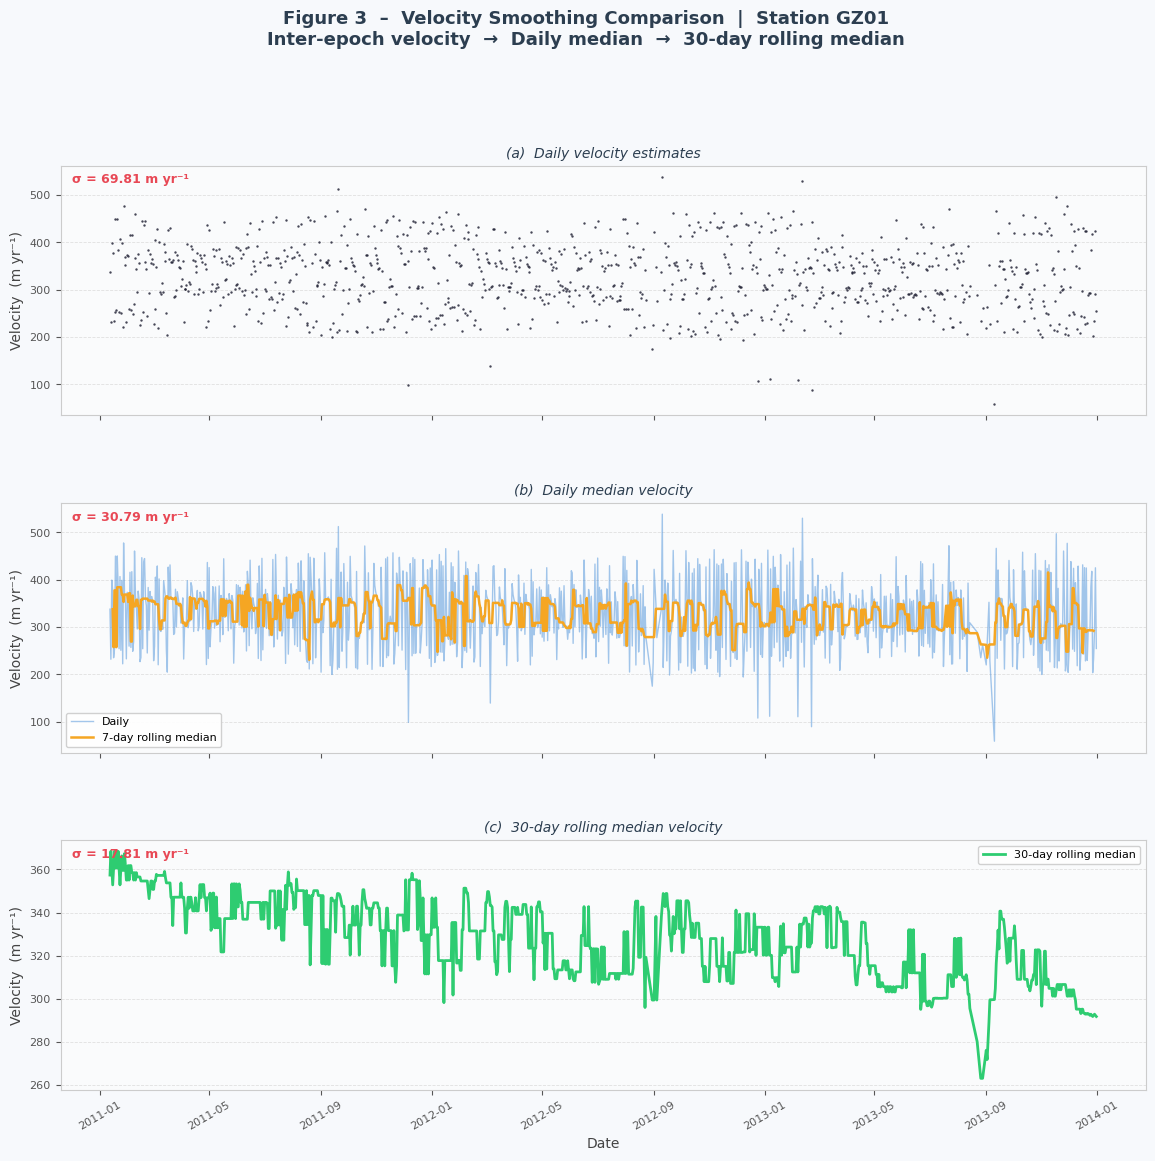

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Getting one station to look at the inter-epoch velocities for 
DATA_FILE  = "../Data/ppp_velocity_timeseries.csv"
OUTPUT_DIR = "../Figures"
OUTPUT_FIG = os.path.join(OUTPUT_DIR, "figure3_velocity_smoothing.pdf")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# This station was choosen because the grounding zone ones experince the fastest velocity 
STATION = "gz01"

# Convert to date time object for calling later 
df = pd.read_csv(DATA_FILE, parse_dates=["timestamp"])
df = df[df["station"] == STATION].dropna(subset=["v"]).sort_values("timestamp").reset_index(drop=True)

# Pulling the needed info from the csv that already went through preprocessing
daily_median = df["v"]
rolling_30d  = df["v_30d"]
timestamps   = df["timestamp"]

# std of the raw daily series vs. the 30-day smoothed series issustrates
noise_daily   = daily_median.std()
noise_30d     = rolling_30d.std()

# Making a three panel figure with for raw scatter, daily median, and 30-day rolling median and a common x-axis for all of them 
fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor="#F7F9FC", sharex=True)
fig.suptitle(
    f"Figure 3  –  Velocity Smoothing Comparison  |  Station {STATION.upper()}\n"
    "Inter-epoch velocity  →  Daily median  →  30-day rolling median",
    fontsize=13, fontweight="bold", color="#2C3E50", y=1.01,
)

plt.subplots_adjust(hspace=0.35)

# Scatter plot with discrete daily estimates
ax1 = axes[0]
ax1.set_facecolor("#FAFBFC")
for spine in ax1.spines.values():
    spine.set_edgecolor("#CCCCCC")
ax1.scatter(timestamps, daily_median, s=3, alpha=0.8, color="#1a1a2e",
            linewidths=0, rasterized=True)
ax1.set_ylabel("Velocity  (m yr⁻¹)", fontsize=10, color="#444")
ax1.set_title("(a)  Daily velocity estimates", fontsize=10,
              color="#2C3E50", fontstyle="italic", pad=6)
ax1.tick_params(labelsize=8, colors="#555")
ax1.yaxis.grid(True, color="#E0E0E0", linestyle="--", linewidth=0.6)
ax1.set_axisbelow(True)
ax1.text(0.01, 0.97, f"σ = {noise_daily:.2f} m yr⁻¹",
         transform=ax1.transAxes, fontsize=9, va="top",
         color="#E84855", fontweight="bold")

# Daily series overlaid with a 7-day rolling median 
ax2 = axes[1]
ax2.set_facecolor("#FAFBFC")
for spine in ax2.spines.values():
    spine.set_edgecolor("#CCCCCC")
ax2.plot(timestamps, daily_median, color="#4A90D9", lw=1.0, alpha=0.5, label="Daily")
ax2.plot(timestamps, daily_median.rolling(7, center=True).median(),
         color="#F5A623", lw=1.8, label="7-day rolling median")
ax2.set_ylabel("Velocity  (m yr⁻¹)", fontsize=10, color="#444")
ax2.set_title("(b)  Daily median velocity", fontsize=10,
              color="#2C3E50", fontstyle="italic", pad=6)
ax2.tick_params(labelsize=8, colors="#555")
ax2.yaxis.grid(True, color="#E0E0E0", linestyle="--", linewidth=0.6)
ax2.set_axisbelow(True)
ax2.legend(fontsize=8, framealpha=0.9, edgecolor="#CCCCCC")
ax2.text(0.01, 0.97, f"σ = {daily_median.rolling(7, center=True).median().std():.2f} m yr⁻¹",
         transform=ax2.transAxes, fontsize=9, va="top",
         color="#E84855", fontweight="bold")

# 30-day rolling median (already computed from extract/preproc)
ax3 = axes[2]
ax3.set_facecolor("#FAFBFC")
for spine in ax3.spines.values():
    spine.set_edgecolor("#CCCCCC")
ax3.plot(timestamps, rolling_30d, color="#2ECC71", lw=2.0, label="30-day rolling median")
ax3.set_ylabel("Velocity  (m yr⁻¹)", fontsize=10, color="#444")
ax3.set_xlabel("Date", fontsize=10, color="#444")
ax3.set_title("(c)  30-day rolling median velocity", fontsize=10,
              color="#2C3E50", fontstyle="italic", pad=6)
ax3.tick_params(labelsize=8, colors="#555")
ax3.tick_params(axis="x", rotation=30)
ax3.yaxis.grid(True, color="#E0E0E0", linestyle="--", linewidth=0.6)
ax3.set_axisbelow(True)
ax3.legend(fontsize=8, framealpha=0.9, edgecolor="#CCCCCC")
ax3.text(0.01, 0.97, f"σ = {noise_30d:.2f} m yr⁻¹",
         transform=ax3.transAxes, fontsize=9, va="top",
         color="#E84855", fontweight="bold")
# Saving the figure 
plt.savefig(
    os.path.join(OUTPUT_DIR, "figure3_velocity_smoothing.png"),
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.savefig(
    os.path.join(OUTPUT_DIR, "figure3_velocity_smoothing.pdf"),
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

## Figure 3 Interpretation 

Figure 3 shows the smoothing that was applied to station GZ01's velocity time series. A station with data spanning roughly 2011-2014. The first panel shows the raw daily estimates, which gives a standard deviation (STD) of 69.81 m/yr. The scatter plot looks spread out between 200 and 400 m/yr, and it's hard to see a clear deceleration trend. In the second panel, a 7-day rolling median is applied. This smoothing cuts the noise in half, giving an STD of 30.79 m/yr. The 7-day window allows for perserving subweekly variability that is likely present with tidal forcings, however, it is still difficult to see a deceleration trend. Finally panel three shows the final stage of smoothing which applies a 30-day rolling median. In this panel, the deceleration trend is more evident, and the STD was cut nearly in half again as compared to panel two, with a value of 19.81 m/yr. Overall, this figure shows how the 30-day rolling median was an effective preprocessing step for smoothing noise and amplifying the signal of the ice sheet velocity's temporal variability.  